Model Comparison:
- Loads the saved train/val/test splits (splits_tau2019_grouped.npz).
- Reuses cached log-mel features for SVM and Random Forest (logmel_stats_all.npz).
- Loads trained models: svm_model.joblib, rf_model.joblib, and cnn_best.pt.
- Evaluates all three models on the **same test set**.
- Computes accuracy, macro F1-score, and confusion matrices.
- Summarizes and compares performance across models.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
import joblib

sns.set(style='whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

SR = 22050
RANDOM_STATE = 42
CNN_CONFIG = {
    'n_mels': 64,
    'hop_length': 320,
    'fmin': 50,
    'fmax': None,
    'max_frames': 256,
    'batch_size': 32,
}

def read_meta(path: str = 'meta.csv') -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError('meta.csv not found')
    meta = pd.read_csv(path, sep='\t', quotechar='"')
    required = ['filename', 'scene_label', 'identifier']
    for c in required:
        if c not in meta:
            raise ValueError(f'Missing {c} in meta')
    meta['filepath'] = meta['filename'].apply(lambda f: os.path.join('.', f))
    return meta


Using device: cpu


In [ ]:
#  SVM and RF
def logmel_stats_from_path(
    path: str,
    sr: int = SR,
    n_mels: int = 128,
    hop_length: int = 1024,
    fmin: int = 50,
    fmax=None,
    use_zscore: bool = True,
    percentiles=(10, 90),
) -> np.ndarray:
    y, sr = librosa.load(path, sr=sr, mono=True)
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels,
        hop_length=hop_length, fmin=fmin, fmax=fmax, power=2.0,
    )
    L = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    if use_zscore:
        mu = float(L.mean())
        sd = float(L.std() + 1e-8)
        L = (L - mu) / sd
    mu = L.mean(axis=1)
    sd = L.std(axis=1)
    p_lo, p_hi = np.percentile(L, percentiles[0], axis=1), np.percentile(L, percentiles[1], axis=1)
    return np.concatenate([mu, sd, p_lo, p_hi]).astype(np.float32)

def build_logmel_stats_matrix(paths, **kwargs):
    feats = [logmel_stats_from_path(p, **kwargs) for p in paths]
    return np.vstack(feats)


In [ ]:
# load splits
meta = read_meta('meta.csv')
splits = np.load('splits_tau2019_grouped.npz')
tr_idx, va_idx, te_idx = splits['tr_idx'], splits['va_idx'], splits['te_idx']
print('Train size:', len(tr_idx), 'Val size:', len(va_idx), 'Test size:', len(te_idx))

filepaths = meta['filepath'].tolist()
labels = meta['scene_label'].to_numpy()

le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = le.classes_
n_classes = len(class_names)
print('Classes:', n_classes, class_names)


Train size: 9309 Val size: 2347 Test size: 2744
Classes: 10 ['airport' 'bus' 'metro' 'metro_station' 'park' 'public_square'
 'shopping_mall' 'street_pedestrian' 'street_traffic' 'tram']


In [ ]:
# build features
if os.path.exists('logmel_stats_all.npz'):
    data = np.load('logmel_stats_all.npz')
    X_all = data['X_all']
    print('Loaded cached log-mel features from logmel_stats_all.npz')
else:
    X_all = build_logmel_stats_matrix(
        filepaths,
        sr=SR,
        n_mels=128,
        hop_length=1024,
        fmin=50,
        fmax=None,
        use_zscore=True,
        percentiles=(10, 90),
    )
    np.savez('logmel_stats_all.npz', X_all=X_all)
    print('Computed and cached log-mel features to logmel_stats_all.npz')
print('Feature matrix shape:', X_all.shape)

X_tr, X_va, X_te = X_all[tr_idx], X_all[va_idx], X_all[te_idx]
y_tr, y_va, y_te = y_all[tr_idx], y_all[va_idx], y_all[te_idx]
X_tr.shape, X_va.shape, X_te.shape


Loaded cached log-mel features from logmel_stats_all.npz
Feature matrix shape: (14400, 512)


((9309, 512), (2347, 512), (2744, 512))

SVM accuracy: 0.5874635568513119
SVM macro F1: 0.5741726539256657
                   precision    recall  f1-score   support

          airport       0.42      0.55      0.47       192
              bus       0.61      0.50      0.55       341
            metro       0.66      0.50      0.57       333
    metro_station       0.49      0.63      0.55       307
             park       0.92      0.71      0.80       403
    public_square       0.40      0.39      0.40       211
    shopping_mall       0.60      0.49      0.54       229
street_pedestrian       0.49      0.53      0.51       282
   street_traffic       0.52      0.84      0.64        97
             tram       0.67      0.75      0.71       349

         accuracy                           0.59      2744
        macro avg       0.58      0.59      0.57      2744
     weighted avg       0.61      0.59      0.59      2744



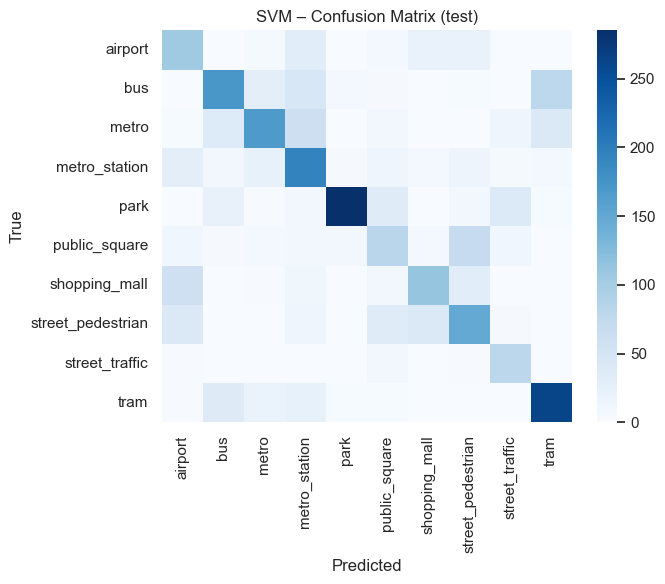

In [ ]:
# Evaluate SVM
if not os.path.exists('svm_model.joblib'):
    raise FileNotFoundError('svm_model.joblib not found. Please run the SVM notebook first.')

svm_model = joblib.load('svm_model.joblib')
y_pred_svm = svm_model.predict(X_te)
acc_svm = accuracy_score(y_te, y_pred_svm)
f1_svm = f1_score(y_te, y_pred_svm, average='macro')
print('SVM accuracy:', acc_svm)
print('SVM macro F1:', f1_svm)
print(classification_report(y_te, y_pred_svm, target_names=class_names))

cm_svm = confusion_matrix(y_te, y_pred_svm)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_svm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM – Confusion Matrix (test)')
plt.tight_layout()
plt.show()


RF accuracy: 0.5543002915451894
RF macro F1: 0.5409295461554773
                   precision    recall  f1-score   support

          airport       0.36      0.43      0.39       192
              bus       0.56      0.57      0.56       341
            metro       0.57      0.45      0.50       333
    metro_station       0.44      0.47      0.45       307
             park       0.86      0.76      0.81       403
    public_square       0.43      0.40      0.41       211
    shopping_mall       0.57      0.64      0.60       229
street_pedestrian       0.45      0.43      0.44       282
   street_traffic       0.50      0.79      0.62        97
             tram       0.61      0.62      0.61       349

         accuracy                           0.55      2744
        macro avg       0.54      0.56      0.54      2744
     weighted avg       0.56      0.55      0.56      2744



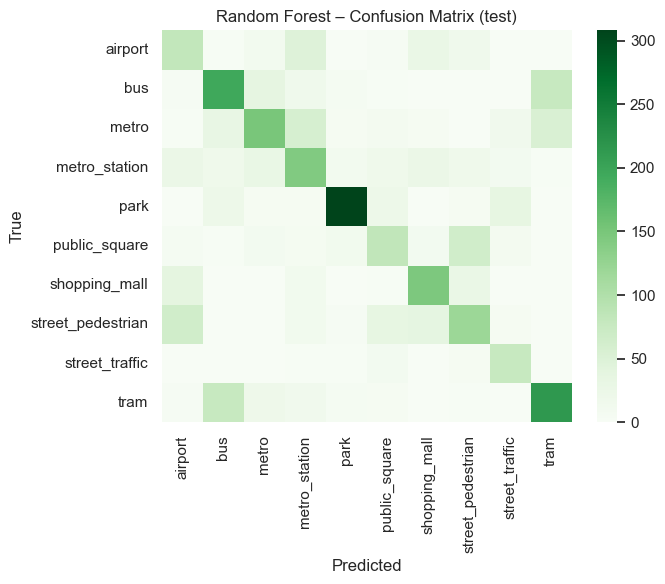

In [ ]:
# Evaluate Random Forest
if not os.path.exists('rf_model.joblib'):
    raise FileNotFoundError('rf_model.joblib not found. Please run the RF notebook first.')

rf_model = joblib.load('rf_model.joblib')
y_pred_rf = rf_model.predict(X_te)
acc_rf = accuracy_score(y_te, y_pred_rf)
f1_rf = f1_score(y_te, y_pred_rf, average='macro')
print('RF accuracy:', acc_rf)
print('RF macro F1:', f1_rf)
print(classification_report(y_te, y_pred_rf, target_names=class_names))

cm_rf = confusion_matrix(y_te, y_pred_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_rf, annot=False, cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Random Forest – Confusion Matrix (test)')
plt.tight_layout()
plt.show()


In [ ]:
# CNN 
class LogMelCNNDataset(Dataset):
    def __init__(
        self,
        meta: pd.DataFrame,
        indices,
        label_encoder: LabelEncoder,
        n_mels: int,
        hop: int,
        fmin: int,
        fmax,
        max_frames: int,
        train: bool,
    ):
        self.meta = meta.reset_index(drop=True)
        self.indices = np.array(indices, dtype=int)
        self.le = label_encoder
        self.n_mels = n_mels
        self.hop = hop
        self.fmin = fmin
        self.fmax = fmax if fmax is not None else SR // 2
        self.max_frames = max_frames
        self.train = train

    def __len__(self):
        return len(self.indices)

    def _wav_to_logmel(self, y: np.ndarray) -> np.ndarray:
        S = librosa.feature.melspectrogram(
            y=y,
            sr=SR,
            n_mels=self.n_mels,
            hop_length=self.hop,
            fmin=self.fmin,
            fmax=self.fmax,
            power=2.0,
        )
        L = librosa.power_to_db(S, ref=np.max).astype(np.float32)
        mu = float(L.mean())
        sd = float(L.std() + 1e-8)
        L = (L - mu) / sd
        return L

    def _pad_or_crop(self, S: np.ndarray) -> np.ndarray:
        T = S.shape[1]
        if T < self.max_frames:
            pad_width = self.max_frames - T
            S = np.pad(S, ((0, 0), (0, pad_width)), mode='constant')
        else:
            S = S[:, : self.max_frames]
        return S

    def __getitem__(self, idx):
        idx = self.indices[idx]
        row = self.meta.iloc[idx]
        path = row['filepath']
        y, _ = librosa.load(path, sr=SR, mono=True)
        S = self._wav_to_logmel(y)
        S = self._pad_or_crop(S)
        x = torch.from_numpy(S).float().unsqueeze(0)
        label_str = row['scene_label']
        y_idx = self.le.transform([label_str])[0]
        y_t = torch.tensor(y_idx, dtype=torch.long)
        return x, y_t

class CRNN(nn.Module):
    def __init__(self, n_classes: int, n_mels: int, n_frames: int):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
        )
        self.freq_bins = n_mels // 8
        self.lstm_input_size = 128 * self.freq_bins
        self.lstm_hidden = 128
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=self.lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(self.lstm_hidden * 2, n_classes)

    def forward(self, x):
        z = self.cnn(x)
        B, C, F, T = z.shape
        z = z.permute(0, 3, 1, 2).contiguous().view(B, T, C * F)
        out, _ = self.lstm(z)
        out = out[:, -1, :]
        logits = self.fc(out)
        return logits


In [ ]:
# CNN test dataset
n_mels = CNN_CONFIG['n_mels']
hop = CNN_CONFIG['hop_length']
fmin = CNN_CONFIG['fmin']
fmax = CNN_CONFIG['fmax']
max_frames = CNN_CONFIG['max_frames']

test_ds_cnn = LogMelCNNDataset(meta, te_idx, le, n_mels, hop, fmin, fmax, max_frames, train=False)
test_loader_cnn = DataLoader(
    test_ds_cnn,
    batch_size=CNN_CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)
len(test_ds_cnn)


2744

C:\Users\haizi\AppData\Local\Temp\ipykernel_5728\3397991726.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('cnn_best.pt', map_location=device)


CNN accuracy: 0.48250728862973763
CNN macro F1: 0.4578224732332454
                   precision    recall  f1-score   support

          airport       0.58      0.16      0.25       192
              bus       0.57      0.42      0.49       341
            metro       0.39      0.50      0.43       333
    metro_station       0.33      0.66      0.44       307
             park       0.86      0.63      0.72       403
    public_square       0.41      0.14      0.21       211
    shopping_mall       0.42      0.76      0.54       229
street_pedestrian       0.51      0.27      0.35       282
   street_traffic       0.51      0.78      0.62        97
             tram       0.57      0.50      0.53       349

         accuracy                           0.48      2744
        macro avg       0.51      0.48      0.46      2744
     weighted avg       0.53      0.48      0.47      2744



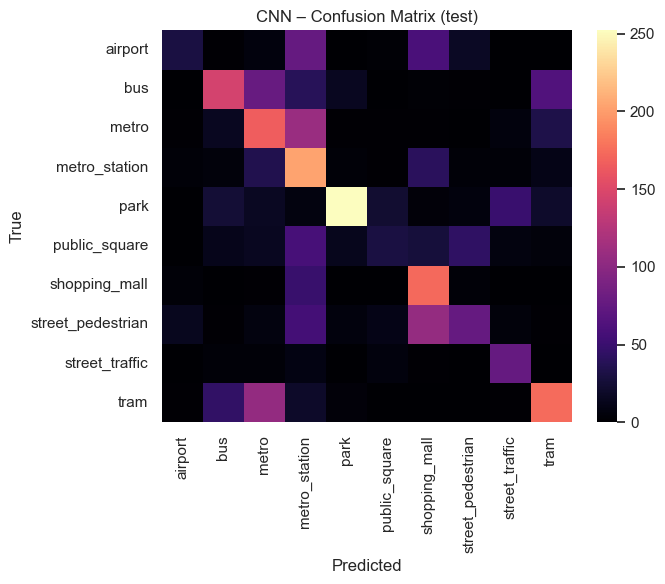

In [ ]:
# load CNN model
if not os.path.exists('cnn_best.pt'):
    raise FileNotFoundError('cnn_best.pt not found. Please run the CNN training notebook first.')

model_cnn = CRNN(n_classes=n_classes, n_mels=n_mels, n_frames=max_frames).to(device)
state_dict = torch.load('cnn_best.pt', map_location=device)
model_cnn.load_state_dict(state_dict)
model_cnn.eval()

all_preds_cnn, all_targets_cnn = [], []
with torch.no_grad():
    for xb, yb in test_loader_cnn:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model_cnn(xb)
        preds = logits.argmax(dim=1)
        all_preds_cnn.append(preds.cpu().numpy())
        all_targets_cnn.append(yb.cpu().numpy())

y_pred_cnn = np.concatenate(all_preds_cnn)
y_true_cnn = np.concatenate(all_targets_cnn)

acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
f1_cnn = f1_score(y_true_cnn, y_pred_cnn, average='macro')
print('CNN accuracy:', acc_cnn)
print('CNN macro F1:', f1_cnn)
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_cnn, annot=False, cmap='magma',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN – Confusion Matrix (test)')
plt.tight_layout()
plt.show()


In [ ]:
# summary
results = pd.DataFrame(
    {
        'model': ['SVM', 'Random Forest', 'CNN'],
        'accuracy': [acc_svm, acc_rf, acc_cnn],
        'macro_f1': [f1_svm, f1_rf, f1_cnn],
    }
).set_index('model')

display(results)

results

,accuracy,macro_f1
model,,
SVM,0.587464,0.574173
Random Forest,0.554300,0.540930
CNN,0.482507,0.457822


,accuracy,macro_f1
model,,
SVM,0.587464,0.574173
Random Forest,0.554300,0.540930
CNN,0.482507,0.457822
